# Latent Lyricism
Emotion-preserving English → Turkish translation using latent space alignment.

**Pipeline overview:**
1. mBERT Sentiment Classifier (frozen backbone + trainable head)
2. Zero-Shot Baseline — XLM-RoBERTa on poem sentiment
3. Fine-Tuned Sentiment Oracle — XLM-RoBERTa fine-tuned → saved as judge
4. Baseline NMT Emotion Preservation — how much emotion is lost in raw translation
5. Latent Lyricism Training — teacher-student NMT with emotion loss (soft bridge)
6. Latent Alignment Training — NMT guided by MSE on sentiment vectors


## 0. Install Dependencies

In [1]:
!pip install transformers torch datasets scikit-learn seaborn matplotlib tqdm

## 1. Imports

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset, concatenate_datasets
from transformers import (
    BertTokenizer, BertModel,
    AutoTokenizer, AutoModelForSequenceClassification,
    XLMRobertaModel,
    MarianMTModel, MarianTokenizer,
)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm


## 2. Configuration

In [3]:
# ── HuggingFace ──────────────────────────────────────────────────────────────
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

# ── Model names ───────────────────────────────────────────────────────────────
MBERT_MODEL_NAME      = 'bert-base-multilingual-cased'
NMT_MODEL_NAME        = 'Helsinki-NLP/opus-mt-tc-big-en-tr'
SENTIMENT_BASE_NAME   = 'cardiffnlp/twitter-xlm-roberta-base-sentiment'

# ── Saved model paths ─────────────────────────────────────────────────────────
SENTIMENT_MODEL_PATH       = 'sentiment_oracle_tuned_roberta.pth'
NMT_LYRICISM_SAVE_PATH     = 'nmt_latent_lyricism_ULTIMATE.pth'
LATENT_ALIGNMENT_SAVE_PATH = 'nmt_latent_alignment_final.pth'
PROJECTOR_SAVE_PATH        = 'projector_latent.pth'

# ── Sequence length ───────────────────────────────────────────────────────────
MAX_LEN = 128

# ── Batch sizes ───────────────────────────────────────────────────────────────
BATCH_SIZE_DEFAULT    = 32  # mBERT phase
BATCH_SIZE_FINETUNE   = 16  # XLM-R fine-tuning & inference
BATCH_SIZE_NMT        = 8   # NMT training (heavier GPU load)

# ── Epochs ────────────────────────────────────────────────────────────────────
EPOCHS_MBERT      = 10
EPOCHS_FINETUNE   = 3
EPOCHS_NMT        = 3
EPOCHS_LATENT     = 3

# ── Learning rates ────────────────────────────────────────────────────────────
LR_HEAD     = 1e-3   # Phase 1: classifier head only
LR_FINETUNE = 2e-5   # Phase 3: XLM-R fine-tuning
LR_NMT      = 1e-5   # Phase 5 & 6: NMT partial fine-tuning

# ── Loss weights ──────────────────────────────────────────────────────────────
CLASS_WEIGHTS_MBERT = [4.0, 4.0, 1.0, 5.0]  # 0:Neg 1:Pos 2:NoImpact 3:Mixed
ALPHA_LYRICISM      = 2.0   # Phase 5: emotion loss multiplier
ALPHA_LATENT        = 10.0  # Phase 6: latent MSE multiplier
GAMMA               = 2.0   # Phase 5: temperature for soft embedding bridge
TOP_K               = 50    # Phase 5: top-k vocab for soft bridge

# ── Architecture dims ─────────────────────────────────────────────────────────
N_CLASSES_MBERT     = 4
N_CLASSES_SENTIMENT = 3
NMT_DIM  = 1024  # Marian decoder hidden size
SENT_DIM = 768   # XLM-RoBERTa hidden size

# ── Label mappings ────────────────────────────────────────────────────────────
# poem_sentiment original: 0:Negative  1:Positive  2:No Impact  3:Mixed
CLASS_NAMES_4 = ['Negative', 'Positive', 'No Impact', 'Mixed']
# Target 3-class:          0:Negative  1:Neutral   2:Positive
CLASS_NAMES_3 = ['Negative', 'Neutral', 'Positive']
# Remap dict (3:Mixed → drop)
LABEL_REMAP_3 = {0: 0, 2: 1, 1: 2}


## 3. Setup: Device, HuggingFace Login & Dataset

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

from huggingface_hub import login
login(HF_TOKEN)

# Load once — all phases reuse these splits
dataset = load_dataset('poem_sentiment')
print(f"Train: {len(dataset['train'])} | Val: {len(dataset['validation'])} | Test: {len(dataset['test'])}")
print('Example:', dataset['train'][0])


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.34k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/6.16k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/892 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/105 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/104 [00:00<?, ? examples/s]

Train: 892 | Val: 105 | Test: 104
Example: {'id': 0, 'verse_text': 'with pale blue berries. in these peaceful shades--', 'label': 1}


## 4. Shared Helpers

In [5]:
def remap_label_3class(original_label):
    """Map 4-class poem_sentiment label to 3-class. Returns None for Mixed (3)."""
    if original_label == 3:
        return None
    return LABEL_REMAP_3[original_label]


def prepare_texts_and_labels(splits):
    """Flatten dataset splits into (texts, labels) lists with Mixed dropped."""
    if isinstance(splits, str):
        splits = [splits]
    combined = concatenate_datasets([dataset[s] for s in splits])
    texts, labels = [], []
    for item in combined:
        mapped = remap_label_3class(item['label'])
        if mapped is None:
            continue
        texts.append(item['verse_text'])
        labels.append(mapped)
    return texts, labels


def plot_confusion_matrix(true_labels, predictions, class_names, title, cmap='Blues'):
    cm = confusion_matrix(true_labels, predictions)
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    plt.figure(figsize=(7, 5))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap=cmap, cbar=False)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


---
## Phase 1: mBERT Sentiment Classifier
Frozen multilingual BERT backbone with a trainable classifier head.
The last encoder layer (layer 11) is unfrozen for task-specific adaptation.

### 1.1 Dataset & DataLoaders

In [6]:
# mBERT tokenizer — cased because capitalisation matters in poetry
mbert_tokenizer = BertTokenizer.from_pretrained(MBERT_MODEL_NAME)


class PoetrySentimentDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len=MAX_LEN):
        self.data = hf_dataset
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, item):
        text  = self.data[item]['verse_text']
        label = self.data[item]['label']
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'text':           text,
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels':         torch.tensor(label, dtype=torch.long),
        }


train_ds_mbert = PoetrySentimentDataset(dataset['train'],      mbert_tokenizer)
val_ds_mbert   = PoetrySentimentDataset(dataset['validation'], mbert_tokenizer)

train_loader_mbert = DataLoader(train_ds_mbert, batch_size=BATCH_SIZE_DEFAULT, shuffle=True)
val_loader_mbert   = DataLoader(val_ds_mbert,   batch_size=BATCH_SIZE_DEFAULT)

print(f'Train batches: {len(train_loader_mbert)} | Val batches: {len(val_loader_mbert)}')


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 28 | Val batches: 4


### 1.2 Model Definition

Freezes all BERT layers except the last encoder layer and the classifier head.

In [7]:
class FrozenBERTClassifier(nn.Module):
    def __init__(self, n_classes):
        super(FrozenBERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(MBERT_MODEL_NAME)

        # Freeze entire backbone
        for param in self.bert.parameters():
            param.requires_grad = False

        # Unfreeze only the last encoder layer (layer 11)
        for param in self.bert.encoder.layer[-1].parameters():
            param.requires_grad = True

        self.drop = nn.Dropout(p=0.3)
        self.out  = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids=None, attention_mask=None, inputs_embeds=None):
        # Supports both standard token input and latent embedding input
        if inputs_embeds is not None:
            outputs = self.bert(inputs_embeds=inputs_embeds, attention_mask=attention_mask)
        else:
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output  # [CLS] token representation
        return self.out(self.drop(pooled))


mbert_model = FrozenBERTClassifier(n_classes=N_CLASSES_MBERT).to(device)
print(f'Trainable params: {sum(p.numel() for p in mbert_model.parameters() if p.requires_grad):,}')


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 7,090,948


### 1.3 Loss, Optimizer & Training Functions

In [8]:
# Weighted loss to handle class imbalance
# Approx. distribution: Neg ~15%, Pos ~13%, No Impact ~62%, Mixed ~5%
class_weights_tensor = torch.tensor(CLASS_WEIGHTS_MBERT).to(device)
loss_fn_mbert = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)
optimizer_mbert = AdamW(mbert_model.parameters(), lr=LR_HEAD)


def train_epoch(model, data_loader, loss_fn, optimizer, device, n_examples):
    model.train()
    losses, correct = [], 0
    for d in data_loader:
        input_ids      = d['input_ids'].to(device)
        attention_mask = d['attention_mask'].to(device)
        targets        = d['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)

        correct += torch.sum(preds == targets)
        losses.append(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    return correct.double() / n_examples, np.mean(losses)


def eval_model(model, data_loader, loss_fn, device, n_examples):
    model.eval()
    losses, correct = [], 0
    with torch.no_grad():
        for d in data_loader:
            input_ids      = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            targets        = d['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)

            correct += torch.sum(preds == targets)
            losses.append(loss.item())

    return correct.double() / n_examples, np.mean(losses)


### 1.4 Training Loop

In [9]:
print(f'Starting training — {EPOCHS_MBERT} epochs, weighted loss')

for epoch in range(EPOCHS_MBERT):
    print(f'Epoch {epoch + 1}/{EPOCHS_MBERT}')

    train_acc, train_loss = train_epoch(
        mbert_model, train_loader_mbert, loss_fn_mbert,
        optimizer_mbert, device, len(dataset['train'])
    )
    val_acc, val_loss = eval_model(
        mbert_model, val_loader_mbert, loss_fn_mbert,
        device, len(dataset['validation'])
    )

    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}')
    print('-' * 40)


Starting training — 10 epochs, weighted loss
Epoch 1/10
  Train Loss: 1.3452 | Train Acc: 0.3386
  Val   Loss: 1.1127 | Val   Acc: 0.5048
----------------------------------------
Epoch 2/10
  Train Loss: 1.2272 | Train Acc: 0.4552
  Val   Loss: 1.1473 | Val   Acc: 0.5143
----------------------------------------
Epoch 3/10
  Train Loss: 1.0949 | Train Acc: 0.5280
  Val   Loss: 1.0318 | Val   Acc: 0.6190
----------------------------------------
Epoch 4/10
  Train Loss: 1.0063 | Train Acc: 0.5774
  Val   Loss: 1.0869 | Val   Acc: 0.4381
----------------------------------------
Epoch 5/10
  Train Loss: 0.9582 | Train Acc: 0.6435
  Val   Loss: 1.0076 | Val   Acc: 0.6667
----------------------------------------
Epoch 6/10
  Train Loss: 0.9133 | Train Acc: 0.7074
  Val   Loss: 1.0693 | Val   Acc: 0.6000
----------------------------------------
Epoch 7/10
  Train Loss: 0.8372 | Train Acc: 0.7029
  Val   Loss: 0.9949 | Val   Acc: 0.5524
----------------------------------------
Epoch 8/10
  Trai

### 1.5 Evaluation

Generating predictions on validation set...

--- Classification Report (mBERT) ---
              precision    recall  f1-score   support

    Negative       0.40      0.84      0.54        19
    Positive       0.25      0.29      0.27        17
   No Impact       0.84      0.55      0.67        69
       Mixed       0.00      0.00      0.00         0

    accuracy                           0.56       105
   macro avg       0.37      0.42      0.37       105
weighted avg       0.67      0.56      0.58       105



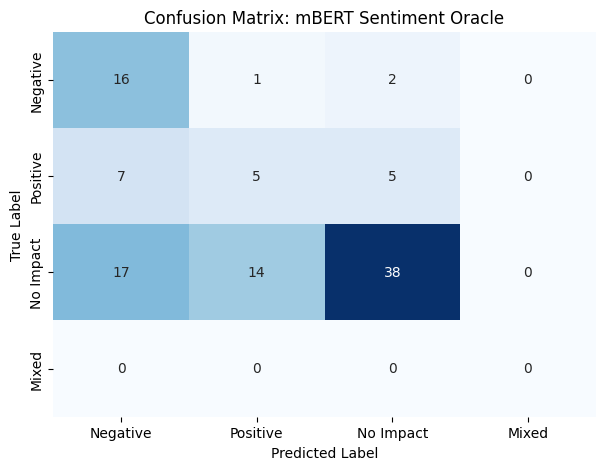

In [11]:
def get_predictions(model, data_loader, device):
    model.eval()
    predictions, real_values = [], []
    with torch.no_grad():
        for d in data_loader:
            input_ids      = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            targets        = d['labels'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds       = torch.max(outputs, dim=1)
            predictions.extend(preds)
            real_values.extend(targets)
    predictions = torch.stack(predictions).cpu().numpy()
    real_values = torch.stack(real_values).cpu().numpy()
    return predictions, real_values


print('Generating predictions on validation set...')
y_pred_mbert, y_true_mbert = get_predictions(mbert_model, val_loader_mbert, device)

print('\n--- Classification Report (mBERT) ---')
print(classification_report(
    y_true_mbert, y_pred_mbert,
    labels=[0, 1, 2, 3], target_names=CLASS_NAMES_4, zero_division=0
))

cm = confusion_matrix(y_true_mbert, y_pred_mbert, labels=[0, 1, 2, 3])
df_cm = pd.DataFrame(cm, index=CLASS_NAMES_4, columns=CLASS_NAMES_4)
plt.figure(figsize=(7, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: mBERT Sentiment Oracle')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

---
## Phase 2: Zero-Shot Baseline — XLM-RoBERTa
Evaluate a pre-trained Twitter XLM-RoBERTa model directly on the full poem dataset
**without any fine-tuning**. Labels: 0→Negative, 1→Neutral, 2→Positive.

Loading Twitter-XLM-RoBERTa (zero-shot)...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

Preparing full dataset (train + val + test)...
Samples after filtering Mixed: 1052
Running zero-shot inference...


 67%|██████▋   | 44/66 [00:00<00:00, 154.43it/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

100%|██████████| 66/66 [00:00<00:00, 152.49it/s]


--- Zero-Shot Classification Report (Full Dataset) ---
              precision    recall  f1-score   support

    Negative       0.50      0.79      0.61       193
     Neutral       0.87      0.72      0.79       693
    Positive       0.65      0.67      0.66       166

    accuracy                           0.72      1052
   macro avg       0.67      0.73      0.69      1052
weighted avg       0.77      0.72      0.73      1052



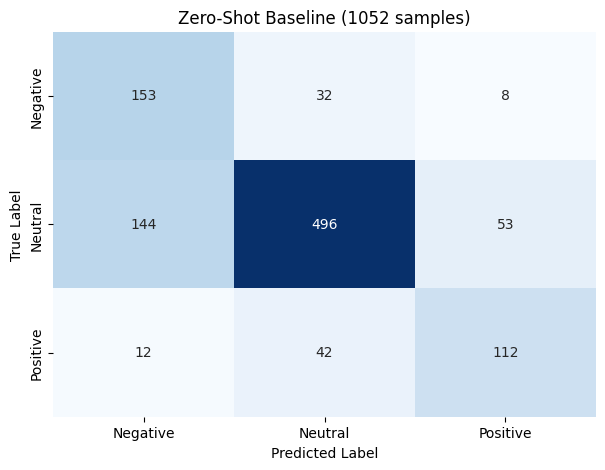

In [12]:
print('Loading Twitter-XLM-RoBERTa (zero-shot)...')
zeroshot_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_BASE_NAME)
zeroshot_model     = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_BASE_NAME)
zeroshot_model     = zeroshot_model.to(device)
zeroshot_model.eval()

# Full dataset: combine all splits
print('Preparing full dataset (train + val + test)...')
texts_zs, true_labels_zs = prepare_texts_and_labels(['train', 'validation', 'test'])
print(f'Samples after filtering Mixed: {len(texts_zs)}')

# Inference
predictions_zs = []
print('Running zero-shot inference...')
with torch.no_grad():
    for i in tqdm(range(0, len(texts_zs), BATCH_SIZE_FINETUNE)):
        batch   = texts_zs[i : i + BATCH_SIZE_FINETUNE]
        inputs  = zeroshot_tokenizer(batch, padding=True, truncation=True,
                                     max_length=MAX_LEN, return_tensors='pt').to(device)
        outputs = zeroshot_model(**inputs)
        probs   = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predictions_zs.extend(torch.argmax(probs, dim=-1).cpu().numpy())

print('\n--- Zero-Shot Classification Report (Full Dataset) ---')
print(classification_report(true_labels_zs, predictions_zs, target_names=CLASS_NAMES_3))

plot_confusion_matrix(
    true_labels_zs, predictions_zs, CLASS_NAMES_3,
    title=f'Zero-Shot Baseline ({len(texts_zs)} samples)', cmap='Blues'
)


---
## Phase 3: Fine-Tuned Sentiment Oracle — XLM-RoBERTa
Fine-tune the Twitter XLM-RoBERTa model on poem sentiment.
The resulting model is saved as `sentiment_oracle_tuned_roberta.pth`
and reused as the **judge** in later phases.

### 3.1 Data Preparation

In [13]:
oracle_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_BASE_NAME)


def prepare_split_oracle(split_name):
    """Tokenize a dataset split; skip Mixed labels."""
    processed = []
    for item in dataset[split_name]:
        mapped = remap_label_3class(item['label'])
        if mapped is None:
            continue
        tokens = oracle_tokenizer(
            item['verse_text'],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        processed.append({
            'input_ids':      tokens['input_ids'].flatten(),
            'attention_mask': tokens['attention_mask'].flatten(),
            'labels':         torch.tensor(mapped, dtype=torch.long),
        })
    return processed


train_data_oracle = prepare_split_oracle('train')
val_data_oracle   = prepare_split_oracle('validation')
test_data_oracle  = prepare_split_oracle('test')

train_loader_oracle    = DataLoader(train_data_oracle, batch_size=BATCH_SIZE_FINETUNE, shuffle=True)
val_loader_oracle      = DataLoader(val_data_oracle,   batch_size=BATCH_SIZE_FINETUNE)
full_eval_data_oracle  = val_data_oracle + test_data_oracle
full_eval_loader_oracle = DataLoader(full_eval_data_oracle, batch_size=BATCH_SIZE_FINETUNE)

print(f'Train: {len(train_data_oracle)} | Full Eval: {len(full_eval_data_oracle)}')


Train: 843 | Full Eval: 209


### 3.2 Training Loop

In [14]:
oracle_model = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_BASE_NAME, num_labels=N_CLASSES_SENTIMENT
).to(device)
optimizer_oracle = AdamW(oracle_model.parameters(), lr=LR_FINETUNE)
loss_fn_oracle   = nn.CrossEntropyLoss().to(device)

print(f'Starting fine-tuning — {EPOCHS_FINETUNE} epochs')
for epoch in range(EPOCHS_FINETUNE):
    oracle_model.train()
    total_loss = 0
    for batch in tqdm(train_loader_oracle, desc=f'Epoch {epoch + 1}/{EPOCHS_FINETUNE}'):
        input_ids = batch['input_ids'].to(device)
        mask      = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)

        optimizer_oracle.zero_grad()
        outputs = oracle_model(input_ids=input_ids, attention_mask=mask)
        loss    = loss_fn_oracle(outputs.logits, labels)
        loss.backward()
        optimizer_oracle.step()
        total_loss += loss.item()

    print(f'  Epoch {epoch + 1} Avg Loss: {total_loss / len(train_loader_oracle):.4f}')


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Starting fine-tuning — 3 epochs


Epoch 1/3: 100%|██████████| 53/53 [00:02<00:00, 21.85it/s]


  Epoch 1 Avg Loss: 0.5695


Epoch 2/3: 100%|██████████| 53/53 [00:02<00:00, 21.95it/s]


  Epoch 2 Avg Loss: 0.2720


Epoch 3/3: 100%|██████████| 53/53 [00:02<00:00, 21.95it/s]

  Epoch 3 Avg Loss: 0.1180


### 3.3 Evaluation & Save

Running final evaluation on (val + test)...


Evaluating: 100%|██████████| 14/14 [00:00<00:00, 72.54it/s]


--- Fine-Tuned Classification Report ---
              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84        38
     Neutral       0.94      0.86      0.90       138
    Positive       0.61      0.85      0.71        33

    accuracy                           0.85       209
   macro avg       0.80      0.85      0.82       209
weighted avg       0.87      0.85      0.86       209



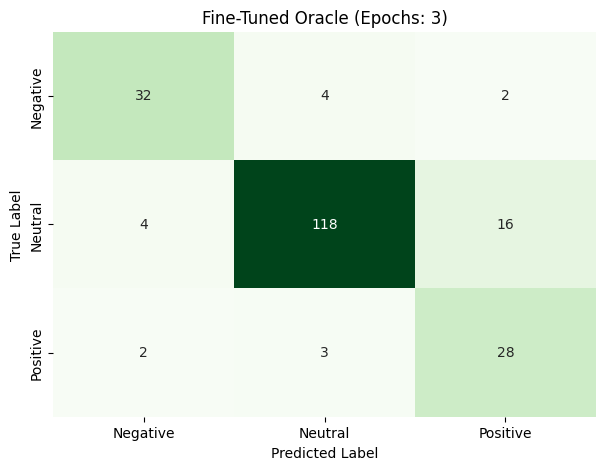

Model saved → 'sentiment_oracle_tuned_roberta.pth'


In [15]:
print('Running final evaluation on (val + test)...')
oracle_model.eval()
preds_oracle, true_oracle = [], []

with torch.no_grad():
    for batch in tqdm(full_eval_loader_oracle, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        mask      = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)
        outputs   = oracle_model(input_ids=input_ids, attention_mask=mask)
        preds_oracle.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        true_oracle.extend(labels.cpu().numpy())

print('\n--- Fine-Tuned Classification Report ---')
print(classification_report(true_oracle, preds_oracle, target_names=CLASS_NAMES_3))

plot_confusion_matrix(
    true_oracle, preds_oracle, CLASS_NAMES_3,
    title=f'Fine-Tuned Oracle (Epochs: {EPOCHS_FINETUNE})', cmap='Greens'
)

torch.save(oracle_model.state_dict(), SENTIMENT_MODEL_PATH)
print(f"Model saved → '{SENTIMENT_MODEL_PATH}'")


---
## Phase 4: Baseline NMT Emotion Preservation
Translate all English verses to Turkish with the **unmodified** Marian NMT model,
then measure how much emotion survives the translation using the fine-tuned oracle.

Loading NMT model (en→tr)...


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading fine-tuned sentiment judge...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Valid verses: 1052
Running translation and sentiment prediction...


100%|██████████| 66/66 [00:04<00:00, 13.84it/s]


=== Baseline Translation Emotion Preservation Report ===
              precision    recall  f1-score   support

    Negative       0.67      0.74      0.70       193
     Neutral       0.88      0.82      0.85       693
    Positive       0.59      0.67      0.63       166

    accuracy                           0.79      1052
   macro avg       0.71      0.75      0.73      1052
weighted avg       0.80      0.79      0.79      1052



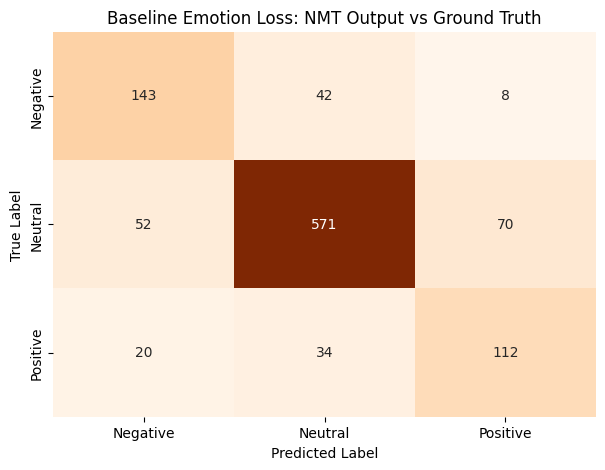


--- Qualitative Analysis: 5 Random Examples ---
[EN]       her eye proclaims her of the briton line:
[TR]       Gözü onu Briton çizgisinden ilan eder:
[True]     Neutral
[Pred]     Neutral
[Status]   ✅ Preserved

[EN]       the quakers' burial-ground.
[TR]       Depremcilerin mezar yeri.
[True]     Neutral
[Pred]     Negative
[Status]   ❌ Lost/Changed

[EN]       but it is not enough, ah! not enough
[TR]       ama yeterli değil, ah! yeterli değil
[True]     Neutral
[Pred]     Neutral
[Status]   ✅ Preserved

[EN]       is shorter than a snake's delay,
[TR]       Yılanın gecikmesinden daha kısa,
[True]     Neutral
[Pred]     Neutral
[Status]   ✅ Preserved

[EN]       sith i might some counsel find
[TR]       Sith belki bazı avukatlar bulur
[True]     Neutral
[Pred]     Neutral
[Status]   ✅ Preserved



In [18]:
# ── Load translation model ───────────────────────────────────────────────────
print('Loading NMT model (en→tr)...')
nmt_tokenizer_baseline = MarianTokenizer.from_pretrained(NMT_MODEL_NAME)
nmt_model_baseline     = MarianMTModel.from_pretrained(NMT_MODEL_NAME).to(device)
nmt_model_baseline.eval()

# ── Load fine-tuned sentiment judge ──────────────────────────────────────────
print('Loading fine-tuned sentiment judge...')
sent_tokenizer_baseline = AutoTokenizer.from_pretrained(SENTIMENT_BASE_NAME)
sent_model_baseline     = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_BASE_NAME, num_labels=N_CLASSES_SENTIMENT
)
sent_model_baseline.load_state_dict(torch.load(SENTIMENT_MODEL_PATH, map_location=device))
sent_model_baseline = sent_model_baseline.to(device)
sent_model_baseline.eval()

# ── Prepare full dataset ──────────────────────────────────────────────────────
texts_baseline, true_labels_baseline = prepare_texts_and_labels(['train', 'validation', 'test'])
print(f'Valid verses: {len(texts_baseline)}')

# ── Inference: Translate then classify ───────────────────────────────────────
translated_tr_baseline = []
predicted_labels_baseline = []

print('Running translation and sentiment prediction...')
with torch.no_grad():
    for i in tqdm(range(0, len(texts_baseline), BATCH_SIZE_FINETUNE)):
        batch_en = texts_baseline[i : i + BATCH_SIZE_FINETUNE]

        # Translate
        nmt_inputs   = nmt_tokenizer_baseline(batch_en, return_tensors='pt', padding=True,
                                              truncation=True, max_length=MAX_LEN).to(device)
        generated_ids = nmt_model_baseline.generate(**nmt_inputs, max_length=MAX_LEN)
        batch_tr      = nmt_tokenizer_baseline.batch_decode(generated_ids, skip_special_tokens=True)
        translated_tr_baseline.extend(batch_tr)

        # Classify Turkish translation
        sent_inputs = sent_tokenizer_baseline(batch_tr, return_tensors='pt', padding=True,
                                              truncation=True, max_length=MAX_LEN).to(device)
        probs       = torch.nn.functional.softmax(sent_model_baseline(**sent_inputs).logits, dim=-1)
        predicted_labels_baseline.extend(torch.argmax(probs, dim=-1).cpu().tolist())

# ── Evaluation ───────────────────────────────────────────────────────────────
print('\n=== Baseline Translation Emotion Preservation Report ===')
print(classification_report(true_labels_baseline, predicted_labels_baseline, target_names=CLASS_NAMES_3))

plot_confusion_matrix(
    true_labels_baseline, predicted_labels_baseline, CLASS_NAMES_3,
    title='Baseline Emotion Loss: NMT Output vs Ground Truth', cmap='Oranges'
)

# ── Qualitative examples ─────────────────────────────────────────────────────
print('\n--- Qualitative Analysis: 5 Random Examples ---')
label_map_rev = {i: name for i, name in enumerate(CLASS_NAMES_3)}
for idx in random.sample(range(len(texts_baseline)), 5):
    preserved = true_labels_baseline[idx] == predicted_labels_baseline[idx]
    status = '✅ Preserved' if preserved else '❌ Lost/Changed'
    print(f'[EN]       {texts_baseline[idx]}')
    print(f'[TR]       {translated_tr_baseline[idx]}')
    print(f'[True]     {label_map_rev[true_labels_baseline[idx]]}')
    print(f'[Pred]     {label_map_rev[predicted_labels_baseline[idx]]}')
    print(f'[Status]   {status}\n')


---
## Phase 5: Latent Lyricism — Emotion Loss Training
Teacher-student NMT training where the student is guided by two objectives:
1. **Translation loss:** match the teacher model's output
2. **Emotion loss:** preserve sentiment via a differentiable soft embedding bridge

Architecture: last 2 decoder layers + `lm_head` are trainable; rest is frozen.

### 5.1 Model Setup

In [19]:
# ── NMT models: student + frozen teacher ────────────────────────────────────
print('Loading NMT teacher and student...')
nmt_tokenizer_p5 = MarianTokenizer.from_pretrained(NMT_MODEL_NAME)

teacher_model_p5 = MarianMTModel.from_pretrained(NMT_MODEL_NAME).to(device)
teacher_model_p5.eval()
for param in teacher_model_p5.parameters():
    param.requires_grad = False

nmt_model_p5 = MarianMTModel.from_pretrained(NMT_MODEL_NAME).to(device)
nmt_model_p5 = nmt_model_p5.to(torch.float32)

# Partial freeze: only last 2 decoder layers + lm_head trainable
for param in nmt_model_p5.parameters():
    param.requires_grad = False
for param in nmt_model_p5.model.decoder.layers[-2:].parameters():
    param.requires_grad = True
for param in nmt_model_p5.lm_head.parameters():
    param.requires_grad = True

# ── Frozen sentiment judge ────────────────────────────────────────────────────
print('Loading frozen sentiment judge...')
sent_tokenizer_p5 = AutoTokenizer.from_pretrained(SENTIMENT_BASE_NAME)
sentiment_model_p5 = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_BASE_NAME, num_labels=N_CLASSES_SENTIMENT
)
sentiment_model_p5.load_state_dict(torch.load(SENTIMENT_MODEL_PATH, map_location=device))
sentiment_model_p5 = sentiment_model_p5.to(device)
sentiment_model_p5.eval()
for param in sentiment_model_p5.parameters():
    param.requires_grad = False

# ── Projector: NMT vocab logits → sentiment embedding space ──────────────────
class ProjectorLayerP5(nn.Module):
    """Projects NMT hidden dim to sentiment model input dim (with Tanh activation)."""
    def __init__(self, input_dim, output_dim):
        super(ProjectorLayerP5, self).__init__()
        self.linear     = nn.Linear(input_dim, output_dim)
        self.activation = nn.Tanh()
    def forward(self, x):
        return self.activation(self.linear(x))

projector_p5 = ProjectorLayerP5(NMT_DIM, SENT_DIM).to(device)
projector_p5 = projector_p5.to(torch.float32)

# ── Dataset ───────────────────────────────────────────────────────────────────
class NMTDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len=MAX_LEN):
        self.data      = hf_dataset
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, item):
        row    = self.data[item]
        mapped = remap_label_3class(row['label'])
        if mapped is None:
            return None
        tokens = self.tokenizer(
            row['verse_text'],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      tokens['input_ids'].flatten(),
            'attention_mask': tokens['attention_mask'].flatten(),
            'labels':         torch.tensor(mapped, dtype=torch.long),
        }

raw_train_p5   = NMTDataset(dataset['train'], nmt_tokenizer_p5)
clean_train_p5 = [d for d in raw_train_p5 if d is not None]
train_loader_p5 = DataLoader(clean_train_p5, batch_size=BATCH_SIZE_NMT, shuffle=True)
print(f'Training samples: {len(clean_train_p5)} | Batches: {len(train_loader_p5)}')


Loading NMT teacher and student...


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading frozen sentiment judge...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training samples: 843 | Batches: 106


### 5.2 Training Loop

In [20]:
def soft_embedding_bridge(logits, embedding_layer, projector, k=TOP_K, gamma=GAMMA):
    """Convert NMT output logits to sentiment-model-compatible embeddings."""
    top_k_values, top_k_indices = torch.topk(logits, k=k, dim=-1)
    # Stabilise to prevent FP16 overflow
    stable_values    = top_k_values - top_k_values.max(dim=-1, keepdim=True).values
    top_k_probs      = torch.softmax(stable_values * gamma, dim=-1)
    top_k_embeddings = embedding_layer(top_k_indices)
    weighted_embeds  = torch.sum(top_k_probs.unsqueeze(-1) * top_k_embeddings, dim=2)
    weighted_embeds  = weighted_embeds.to(projector.linear.weight.dtype)
    return projector(weighted_embeds)


sent_criterion_p5     = nn.CrossEntropyLoss()
trainable_nmt_params  = filter(lambda p: p.requires_grad, nmt_model_p5.parameters())
optimizer_p5          = AdamW(list(trainable_nmt_params) + list(projector_p5.parameters()), lr=LR_NMT)
scaler_p5             = torch.amp.GradScaler('cuda')

print(f'--- Latent Lyricism Training ({EPOCHS_NMT} epochs, α={ALPHA_LYRICISM}) ---')

for epoch in range(EPOCHS_NMT):
    print(f'\n{"="*15} EPOCH {epoch + 1}/{EPOCHS_NMT} {"="*15}')
    for step, batch in enumerate(train_loader_p5):
        input_ids        = batch['input_ids'].to(device).contiguous()
        mask             = batch['attention_mask'].to(device).contiguous()
        target_sentiment = batch['labels'].to(device).contiguous()

        # Teacher reference translation (frozen, no grad)
        with torch.no_grad():
            generated_ids = teacher_model_p5.generate(input_ids, attention_mask=mask, max_length=MAX_LEN)
            generated_ids = generated_ids.contiguous()
            generated_ids[generated_ids == nmt_tokenizer_p5.pad_token_id] = -100

        nmt_model_p5.train()
        projector_p5.train()
        optimizer_p5.zero_grad()

        with torch.amp.autocast('cuda'):
            nmt_outputs  = nmt_model_p5(input_ids=input_ids, attention_mask=mask, labels=generated_ids)
            trans_loss   = nmt_outputs.loss

            embed_layer  = nmt_model_p5.get_input_embeddings()
            soft_embeds  = soft_embedding_bridge(nmt_outputs.logits, embed_layer, projector_p5)

            sent_outputs = sentiment_model_p5(inputs_embeds=soft_embeds)
            emotion_loss = sent_criterion_p5(sent_outputs.logits, target_sentiment)

            total_loss   = trans_loss + ALPHA_LYRICISM * emotion_loss

        scaler_p5.scale(total_loss).backward()
        scaler_p5.unscale_(optimizer_p5)

        params_to_clip = (
            list(filter(lambda p: p.requires_grad, nmt_model_p5.parameters())) +
            list(projector_p5.parameters())
        )
        torch.nn.utils.clip_grad_norm_(params_to_clip, 1.0)

        scaler_p5.step(optimizer_p5)
        scaler_p5.update()

        if step % 20 == 0:
            print(f'  Step {step:03d} | Total: {total_loss.item():.4f} '
                  f'| Trans: {trans_loss.item():.4f} | Emotion: {emotion_loss.item():.4f}')

torch.save(nmt_model_p5.state_dict(), NMT_LYRICISM_SAVE_PATH)
print(f"\nTraining complete → '{NMT_LYRICISM_SAVE_PATH}'")


--- Latent Lyricism Training (3 epochs, α=2.0) ---

=============== EPOCH 1/3 ===============
  Step 000 | Total: 6.5658 | Trans: 0.9554 | Emotion: 2.8052
  Step 020 | Total: 6.1317 | Trans: 0.8248 | Emotion: 2.6535
  Step 040 | Total: 2.0232 | Trans: 0.8167 | Emotion: 0.6032
  Step 060 | Total: 4.9163 | Trans: 0.6559 | Emotion: 2.1302
  Step 080 | Total: 4.6167 | Trans: 0.8263 | Emotion: 1.8952
  Step 100 | Total: 4.3724 | Trans: 0.6704 | Emotion: 1.8510

=============== EPOCH 2/3 ===============
  Step 000 | Total: 0.8338 | Trans: 0.6455 | Emotion: 0.0942
  Step 020 | Total: 0.9741 | Trans: 0.6710 | Emotion: 0.1516
  Step 040 | Total: 2.6546 | Trans: 0.6578 | Emotion: 0.9984
  Step 060 | Total: 3.3144 | Trans: 0.7699 | Emotion: 1.2722
  Step 080 | Total: 1.5229 | Trans: 0.4278 | Emotion: 0.5475
  Step 100 | Total: 2.3449 | Trans: 0.5089 | Emotion: 0.9180

=============== EPOCH 3/3 ===============
  Step 000 | Total: 2.6018 | Trans: 0.4865 | Emotion: 1.0577
  Step 020 | Total: 2.0313 

### 5.3 Evaluation — Baseline vs Trained

In [21]:
print('Loading fresh base model for comparison...')
base_model_p5 = MarianMTModel.from_pretrained(NMT_MODEL_NAME).to(device)
base_model_p5.eval()
nmt_model_p5.eval()

texts_p5, true_labels_p5 = prepare_texts_and_labels(['train', 'validation', 'test'])

base_preds_p5, trained_preds_p5 = [], []
base_tr_p5, trained_tr_p5 = [], []

print('Running inference...')
with torch.no_grad():
    for i in tqdm(range(0, len(texts_p5), BATCH_SIZE_FINETUNE)):
        batch_en = texts_p5[i : i + BATCH_SIZE_FINETUNE]
        inputs   = nmt_tokenizer_p5(batch_en, return_tensors='pt', padding=True,
                                    truncation=True, max_length=MAX_LEN).to(device)

        base_tr_p5.extend(nmt_tokenizer_p5.batch_decode(
            base_model_p5.generate(**inputs, max_length=MAX_LEN), skip_special_tokens=True))
        trained_tr_p5.extend(nmt_tokenizer_p5.batch_decode(
            nmt_model_p5.generate(**inputs, max_length=MAX_LEN), skip_special_tokens=True))

        for translations, preds_list in [
            (base_tr_p5[-len(batch_en):], base_preds_p5),
            (trained_tr_p5[-len(batch_en):], trained_preds_p5),
        ]:
            s_inputs = sent_tokenizer_p5(translations, return_tensors='pt', padding=True,
                                         truncation=True, max_length=MAX_LEN).to(device)
            preds_list.extend(torch.argmax(sentiment_model_p5(**s_inputs).logits, dim=-1).cpu().tolist())

base_acc_p5    = accuracy_score(true_labels_p5, base_preds_p5) * 100
trained_acc_p5 = accuracy_score(true_labels_p5, trained_preds_p5) * 100

print(f'\n📊 Results:')
print(f'  Base NMT accuracy    : {base_acc_p5:.2f}%')
print(f'  Trained NMT accuracy : {trained_acc_p5:.2f}%')
print(f'  Improvement          : {trained_acc_p5 - base_acc_p5:+.2f}%')
print('\n--- Trained Model Classification Report ---')
print(classification_report(true_labels_p5, trained_preds_p5, target_names=CLASS_NAMES_3))

print('\n--- Example Differences (base wrong, trained correct) ---')
found = False
for i in range(len(texts_p5)):
    if base_preds_p5[i] != true_labels_p5[i] and trained_preds_p5[i] == true_labels_p5[i]:
        print(f'[EN]         {texts_p5[i]}')
        print(f'[True]       {CLASS_NAMES_3[true_labels_p5[i]]}')
        print(f'[Base TR]    {base_tr_p5[i]}  → {CLASS_NAMES_3[base_preds_p5[i]]} ❌')
        print(f'[Trained TR] {trained_tr_p5[i]}  → {CLASS_NAMES_3[trained_preds_p5[i]]} ✅')
        print('-' * 50)
        found = True
if not found:
    print('No clear win found in this test set.')

del base_model_p5
torch.cuda.empty_cache()


Loading fresh base model for comparison...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Running inference...


100%|██████████| 66/66 [00:11<00:00,  5.84it/s]


📊 Results:
  Base NMT accuracy    : 78.52%
  Trained NMT accuracy : 77.76%
  Improvement          : -0.76%

--- Trained Model Classification Report ---
              precision    recall  f1-score   support

    Negative       0.65      0.74      0.69       193
     Neutral       0.88      0.81      0.84       693
    Positive       0.59      0.69      0.64       166

    accuracy                           0.78      1052
   macro avg       0.71      0.75      0.72      1052
weighted avg       0.79      0.78      0.78      1052


--- Example Differences (base wrong, trained correct) ---
[EN]         sounded o'er earth and sea its blast of war,
[True]       Negative
[Base TR]    Yerin ve denizin uğultusunu,  → Neutral ❌
[Trained TR] Yer ve deniz, onun savaş üfürüşünü seslendirdi.  → Negative ✅
--------------------------------------------------
[EN]         they were wet, and glistened with raindrops, shed
[True]       Neutral
[Base TR]    Islaktılar ve yağmur damlalarıyla parıldadılar, d

---
## Phase 6: Latent Alignment — MSE Distance Minimization
Instead of a classification emotion loss, this phase minimises the **geometric distance**
between English and Turkish sentiment vectors in the XLM-RoBERTa latent space.

Key changes from Phase 5:
- Referee is the **XLM-RoBERTa backbone** (not the classification head)
- Loss = MSE between English [CLS] vector and the projected Turkish decoder output
- Projector has **no activation** (linear only) to preserve the full vector range

### 6.1 Model Setup

In [22]:
# ── Referee: XLM-RoBERTa backbone (feature extractor, fully frozen) ──────────
print('Loading XLM-RoBERTa backbone (referee)...')
sent_tokenizer_p6  = AutoTokenizer.from_pretrained(SENTIMENT_BASE_NAME)
referee_model_p6   = XLMRobertaModel.from_pretrained(SENTIMENT_BASE_NAME).to(device)
referee_model_p6.eval()
for param in referee_model_p6.parameters():
    param.requires_grad = False

# ── NMT teacher + student ─────────────────────────────────────────────────────
print('Loading NMT teacher and student...')
nmt_tokenizer_p6 = MarianTokenizer.from_pretrained(NMT_MODEL_NAME)

teacher_model_p6 = MarianMTModel.from_pretrained(NMT_MODEL_NAME).to(device)
teacher_model_p6.eval()
for param in teacher_model_p6.parameters():
    param.requires_grad = False

nmt_model_p6 = MarianMTModel.from_pretrained(NMT_MODEL_NAME).to(device)
nmt_model_p6 = nmt_model_p6.to(torch.float32)

for param in nmt_model_p6.parameters():
    param.requires_grad = False
for param in nmt_model_p6.model.decoder.layers[-2:].parameters():
    param.requires_grad = True
for param in nmt_model_p6.lm_head.parameters():
    param.requires_grad = True

# ── Projector: NMT decoder (1024) → XLM-RoBERTa (768), linear only ───────────
# Note: no Tanh — XLM-R embeddings have wide distribution; activation would clip them
class ProjectorLayerP6(nn.Module):
    def __init__(self, input_dim=NMT_DIM, output_dim=SENT_DIM):
        super(ProjectorLayerP6, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
    def forward(self, x):
        return self.linear(x)

projector_p6 = ProjectorLayerP6().to(device)
projector_p6 = projector_p6.to(torch.float32)

# ── Dataset: stores raw English text for the referee ─────────────────────────
class LatentDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_len=MAX_LEN):
        self.data      = [row for row in hf_dataset if row['label'] != 3]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, item):
        text   = self.data[item]['verse_text']
        tokens = self.tokenizer(text, max_length=self.max_len, padding='max_length',
                                truncation=True, return_tensors='pt')
        return {
            'english_text':   text,   # kept as string for the referee
            'input_ids':      tokens['input_ids'].flatten(),
            'attention_mask': tokens['attention_mask'].flatten(),
        }

train_data_p6   = LatentDataset(dataset['train'], nmt_tokenizer_p6)
train_loader_p6 = DataLoader(train_data_p6, batch_size=BATCH_SIZE_NMT, shuffle=True)
print(f'Training samples: {len(train_data_p6)} | Batches: {len(train_loader_p6)}')


Loading XLM-RoBERTa backbone (referee)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.weight      | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading NMT teacher and student...


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Training samples: 843 | Batches: 106


### 6.2 Training Loop

In [23]:
latent_criterion_p6  = nn.MSELoss()
trainable_nmt_p6     = filter(lambda p: p.requires_grad, nmt_model_p6.parameters())
optimizer_p6         = AdamW(list(trainable_nmt_p6) + list(projector_p6.parameters()), lr=LR_NMT)
scaler_p6            = torch.amp.GradScaler('cuda')

print(f'--- Latent Alignment Training ({EPOCHS_LATENT} epochs, α={ALPHA_LATENT}) ---')

for epoch in range(EPOCHS_LATENT):
    print(f'\n{"="*15} EPOCH {epoch + 1}/{EPOCHS_LATENT} {"="*15}')
    for step, batch in enumerate(train_loader_p6):
        input_ids    = batch['input_ids'].to(device).contiguous()
        nmt_mask     = batch['attention_mask'].to(device).contiguous()
        english_texts = batch['english_text']

        # A: Referee — English sentiment vector (target)
        with torch.no_grad():
            sent_inputs       = sent_tokenizer_p6(english_texts, return_tensors='pt', padding=True,
                                                  truncation=True, max_length=MAX_LEN).to(device)
            en_outputs        = referee_model_p6(**sent_inputs)
            en_sentiment_vec  = en_outputs.pooler_output   # (B, 768)

        # B: Teacher — reference translation labels
        with torch.no_grad():
            generated_ids  = teacher_model_p6.generate(input_ids, attention_mask=nmt_mask, max_length=MAX_LEN)
            tr_target_mask = (generated_ids != nmt_tokenizer_p6.pad_token_id).long().to(device)
            labels         = generated_ids.clone()
            labels[labels == nmt_tokenizer_p6.pad_token_id] = -100

        # C: Student forward
        nmt_model_p6.train()
        projector_p6.train()
        optimizer_p6.zero_grad()

        with torch.amp.autocast('cuda'):
            nmt_outputs           = nmt_model_p6(input_ids=input_ids, attention_mask=nmt_mask,
                                                 labels=labels, output_hidden_states=True)
            trans_loss            = nmt_outputs.loss

            # D: Latent bridge — project decoder output into referee space
            decoder_hidden        = nmt_outputs.decoder_hidden_states[-1]   # (B, S, 1024)
            projected_embeds      = projector_p6(decoder_hidden)            # (B, S, 768)

            tr_outputs            = referee_model_p6(inputs_embeds=projected_embeds,
                                                     attention_mask=tr_target_mask)
            tr_sentiment_vec      = tr_outputs.pooler_output                # (B, 768)

            # E: MSE between English and Turkish sentiment vectors
            latent_loss  = latent_criterion_p6(tr_sentiment_vec, en_sentiment_vec)
            total_loss   = trans_loss + ALPHA_LATENT * latent_loss

        # F: Backward pass
        scaler_p6.scale(total_loss).backward()
        scaler_p6.unscale_(optimizer_p6)

        params_to_clip = (
            list(filter(lambda p: p.requires_grad, nmt_model_p6.parameters())) +
            list(projector_p6.parameters())
        )
        torch.nn.utils.clip_grad_norm_(params_to_clip, 1.0)

        scaler_p6.step(optimizer_p6)
        scaler_p6.update()

        if step % 20 == 0:
            print(f'  Step {step:03d} | Total: {total_loss.item():.4f} '
                  f'| Trans: {trans_loss.item():.4f} | Latent MSE: {latent_loss.item():.4f}')

torch.save(nmt_model_p6.state_dict(), LATENT_ALIGNMENT_SAVE_PATH)
torch.save(projector_p6.state_dict(), PROJECTOR_SAVE_PATH)
print(f"\nTraining complete → '{LATENT_ALIGNMENT_SAVE_PATH}' + '{PROJECTOR_SAVE_PATH}'")


--- Latent Alignment Training (3 epochs, α=10.0) ---

=============== EPOCH 1/3 ===============
  Step 000 | Total: 1.9810 | Trans: 1.1037 | Latent MSE: 0.0877
  Step 020 | Total: 1.5844 | Trans: 0.8454 | Latent MSE: 0.0739
  Step 040 | Total: 1.6382 | Trans: 1.0146 | Latent MSE: 0.0624
  Step 060 | Total: 1.3178 | Trans: 0.6832 | Latent MSE: 0.0635
  Step 080 | Total: 1.5094 | Trans: 0.7981 | Latent MSE: 0.0711
  Step 100 | Total: 1.3049 | Trans: 0.7409 | Latent MSE: 0.0564

=============== EPOCH 2/3 ===============
  Step 000 | Total: 1.6685 | Trans: 0.9942 | Latent MSE: 0.0674
  Step 020 | Total: 1.4271 | Trans: 0.8118 | Latent MSE: 0.0615
  Step 040 | Total: 1.1072 | Trans: 0.5508 | Latent MSE: 0.0556
  Step 060 | Total: 1.3420 | Trans: 0.7418 | Latent MSE: 0.0600
  Step 080 | Total: 1.2673 | Trans: 0.6158 | Latent MSE: 0.0651
  Step 100 | Total: 1.0709 | Trans: 0.5409 | Latent MSE: 0.0530

=============== EPOCH 3/3 ===============
  Step 000 | Total: 0.9503 | Trans: 0.5405 | Laten

### 6.3 Evaluation — Baseline vs Latent Aligned

In [26]:
print('Loading fresh base model for comparison...')
base_model_p6 = MarianMTModel.from_pretrained(NMT_MODEL_NAME).to(device)
base_model_p6.eval()
nmt_model_p6.eval()

# Load fine-tuned sentiment model as the evaluator
print('Loading fine-tuned sentiment judge for evaluation...')
eval_sent_tokenizer_p6 = AutoTokenizer.from_pretrained(SENTIMENT_BASE_NAME)
eval_sent_model_p6     = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_BASE_NAME, num_labels=N_CLASSES_SENTIMENT
)
eval_sent_model_p6.load_state_dict(torch.load(SENTIMENT_MODEL_PATH, map_location=device))
eval_sent_model_p6 = eval_sent_model_p6.to(device)
eval_sent_model_p6.eval()

# Test split only
texts_p6, true_labels_p6 = prepare_texts_and_labels('test')
print(f'Test samples: {len(texts_p6)}')

base_preds_p6, trained_preds_p6 = [], []
base_tr_p6, trained_tr_p6 = [], []

print('Running inference...')
with torch.no_grad():
    for i in tqdm(range(0, len(texts_p6), BATCH_SIZE_FINETUNE)):
        batch_en = texts_p6[i : i + BATCH_SIZE_FINETUNE]
        inputs   = nmt_tokenizer_p6(batch_en, return_tensors='pt', padding=True,
                                    truncation=True, max_length=MAX_LEN).to(device)

        base_tr_p6.extend(nmt_tokenizer_p6.batch_decode(
            base_model_p6.generate(**inputs, max_length=MAX_LEN), skip_special_tokens=True))
        trained_tr_p6.extend(nmt_tokenizer_p6.batch_decode(
            nmt_model_p6.generate(**inputs, max_length=MAX_LEN), skip_special_tokens=True))

        for translations, preds_list in [
            (base_tr_p6[-len(batch_en):], base_preds_p6),
            (trained_tr_p6[-len(batch_en):], trained_preds_p6),
        ]:
            s_in = eval_sent_tokenizer_p6(translations, return_tensors='pt', padding=True,
                                          truncation=True, max_length=MAX_LEN).to(device)
            preds_list.extend(torch.argmax(eval_sent_model_p6(**s_in).logits, dim=-1).cpu().tolist())

base_acc_p6    = accuracy_score(true_labels_p6, base_preds_p6) * 100
trained_acc_p6 = accuracy_score(true_labels_p6, trained_preds_p6) * 100

print(f'\n📊 Results (Test Set):')
print(f'  Base NMT accuracy         : {base_acc_p6:.2f}%')
print(f'  Latent Aligned accuracy   : {trained_acc_p6:.2f}%')
print(f'  Improvement               : {trained_acc_p6 - base_acc_p6:+.2f}%')
print('\n--- Latent Aligned Model Classification Report ---')
print(classification_report(true_labels_p6, trained_preds_p6, target_names=CLASS_NAMES_3))

print('\n--- Example Differences (base wrong, trained correct) ---')
found = False
for i in range(len(texts_p6)):
    if base_preds_p6[i] != true_labels_p6[i] and trained_preds_p6[i] == true_labels_p6[i]:
        print(f'[EN]          {texts_p6[i]}')
        print(f'[True]        {CLASS_NAMES_3[true_labels_p6[i]]}')
        print(f'[Base TR]     {base_tr_p6[i]}  → {CLASS_NAMES_3[base_preds_p6[i]]} ❌')
        print(f'[Latent TR]   {trained_tr_p6[i]}  → {CLASS_NAMES_3[trained_preds_p6[i]]} ✅')
        found = True
        break
if not found:
    print('No clear win found in this test set.')

del base_model_p6, eval_sent_model_p6
torch.cuda.empty_cache()


Loading fresh base model for comparison...


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading fine-tuned sentiment judge for evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test samples: 104
Running inference...


100%|██████████| 7/7 [00:00<00:00,  7.80it/s]


📊 Results (Test Set):
  Base NMT accuracy         : 78.85%
  Latent Aligned accuracy   : 80.77%
  Improvement               : +1.92%

--- Latent Aligned Model Classification Report ---
              precision    recall  f1-score   support

    Negative       0.62      0.79      0.70        19
     Neutral       0.89      0.86      0.87        69
    Positive       0.71      0.62      0.67        16

    accuracy                           0.81       104
   macro avg       0.74      0.76      0.75       104
weighted avg       0.82      0.81      0.81       104


--- Example Differences (base wrong, trained correct) ---
[EN]          indignantly i hurled the cry:
[True]        Negative
[Base TR]     Öfkeyle haykırdım:  → Neutral ❌
[Latent TR]   Öfkeyle çığlık attım:  → Negative ✅
